In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from src.utils import get_latest_file
from src.config import *
from src.modeling import *
from sklearn.metrics import classification_report, roc_auc_score

from datetime import datetime


# ## 1. Chargement des données

In [2]:
dataset_path = get_latest_file(DATA_FINAL_CLEANED_DATASET_DIR)
df = pd.read_csv(dataset_path)

target = 'IS_WIN'


# On applique le même préprocessing que d'habitude
X = prepare_model_input(df, target=target, drop_odds=False, drop_player_absent=True, verbose=True)
y = df.loc[X.index, target]

# ## 2. Analyse de corrélation


In [3]:
corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

corr_threshold = 0.99

high_corr_cols = [column for column in upper_triangle.columns if any(upper_triangle[column] > corr_threshold)]
print(f"Colonnes à retirer pour corrélation > {corr_threshold} : {len(high_corr_cols)}")

print(high_corr_cols)

X_reduced_corr = X.drop(columns=high_corr_cols)
y_reduced_corr = y.loc[X_reduced_corr.index]


Colonnes à retirer pour corrélation > 0.99 : 304
['ROLL_threePointersMade_traditional_50', 'ROLL_threePointersMade_traditional_100', 'ROLL_threePointersMade_traditional_200', 'ROLL_threePointersAttempted_traditional_5', 'ROLL_threePointersAttempted_traditional_10', 'ROLL_threePointersAttempted_traditional_50', 'ROLL_threePointersAttempted_traditional_100', 'ROLL_threePointersAttempted_traditional_200', 'ROLL_pace_advanced_10', 'ROLL_pace_advanced_25', 'ROLL_pace_advanced_50', 'ROLL_pace_advanced_100', 'ROLL_pace_advanced_200', 'ROLL_percentageFieldGoalsAttempted2pt_scoring_5', 'ROLL_percentageFieldGoalsAttempted2pt_scoring_10', 'ROLL_percentageFieldGoalsAttempted2pt_scoring_50', 'ROLL_percentageFieldGoalsAttempted2pt_scoring_100', 'ROLL_percentageFieldGoalsAttempted2pt_scoring_200', 'ROLL_percentageFieldGoalsAttempted3pt_scoring_3', 'ROLL_percentageFieldGoalsAttempted3pt_scoring_5', 'ROLL_percentageFieldGoalsAttempted3pt_scoring_10', 'ROLL_percentageFieldGoalsAttempted3pt_scoring_25', 

# Bloc PCA – Réduction de dimension

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardisation indispensable avant PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced_corr)


# Lancement PCA : garder 95% de la variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"✅ PCA terminé. Nombre de composantes conservées : {X_pca.shape[1]} (sur {X_reduced_corr.shape[1]} features)")


✅ PCA terminé. Nombre de composantes conservées : 164 (sur 1149 features)


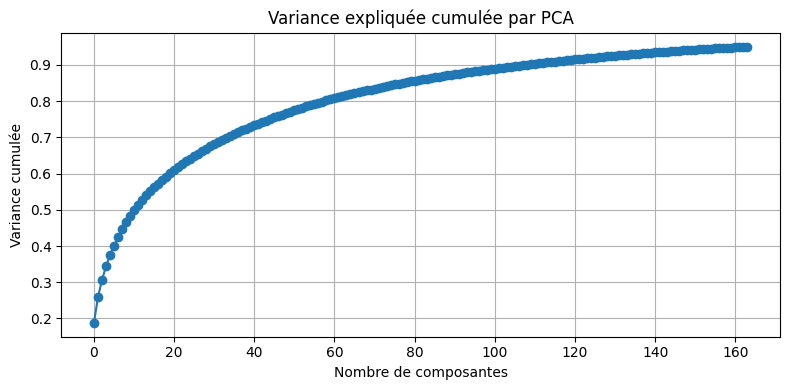

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title('Variance expliquée cumulée par PCA')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance cumulée')
plt.grid(True)
plt.tight_layout()
plt.show()


# Split temporel : 80% des premières lignes pour entraînement, 20% dernières pour test

In [6]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# X_reduced_corr_train, X_reduced_corr_test, y_reduced_corr_train, y_reduced_corr_test = train_test_split(
#     X_reduced_corr, y_reduced_corr, test_size=0.2, random_state=42
# )

# X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
#     X_pca, y_reduced_corr, test_size=0.2, random_state=42
# )

# split temporel

split_index = int(len(X_reduced_corr) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


X_reduced_corr_train = X_reduced_corr.iloc[:split_index]
X_reduced_corr_test = X_reduced_corr.iloc[split_index:]

y_reduced_corr_train = y_reduced_corr.iloc[:split_index]
y_reduced_corr_test = y_reduced_corr.iloc[split_index:]

X_train_pca = X_pca[:split_index]
X_test_pca = X_pca[split_index:]

y_train_pca = y_reduced_corr.iloc[:split_index]
y_test_pca = y_reduced_corr.iloc[split_index:]


# Visualisation de la distribution du target

In [7]:
# plt.figure(figsize=(6, 4))
# sns.countplot(x=y)
# plt.title("Répartition des classes (IS_WIN)")
# plt.show()


# Matrice de corrélation des features les plus importantes

In [8]:
# Matrice de corrélation des features nettoyées (top 20 en moyenne)
# top_cleaned = X_reduced_corr.mean().sort_values(ascending=False).head(500).index
# plt.figure(figsize=(30, 30))
# sns.heatmap(X_reduced_corr[top_cleaned].corr(), annot=False, fmt=".2f", cmap="coolwarm")
# plt.title("Corrélation des 20 features nettoyées les plus influentes")
# plt.tight_layout()
# plt.show()

# Entraînement LGBM


In [9]:
import lightgbm as lgb

def run_lgbm_eval(Xtr, ytr, Xte, yte, name):
    start_time = datetime.now()
    model = lgb.LGBMClassifier(n_estimators=200, random_state=42)
    _, _, metrics = evaluate_model(model, Xtr, ytr, Xte, yte, name=name)
    metrics["train_time"] = (datetime.now() - start_time).total_seconds()
    return metrics

results_lgbm = [
    run_lgbm_eval(X_reduced_corr_train, y_reduced_corr_train, X_reduced_corr_test, y_reduced_corr_test, "LGBM_reduced"),
    run_lgbm_eval(X_train_pca, y_train_pca, X_test_pca, y_test_pca, "LGBM_PCA"),
    run_lgbm_eval(X_train, y_train, X_test, y_test, "LGBM_all"),
]

results_lgbm_df = pd.concat(results_lgbm, ignore_index=True)
display(results_lgbm_df)

[LightGBM] [Info] Number of positive: 15221, number of negative: 15243
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.162608 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 278883
[LightGBM] [Info] Number of data points in the train set: 30464, number of used features: 1136
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499639 -> initscore=-0.001444
[LightGBM] [Info] Start training from score -0.001444
========= LGBM_reduced evaluation =========
[LightGBM] [Info] Number of positive: 15221, number of negative: 15243
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006942 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41820
[LightGBM] [Info] Number of data points in the train set: 30464, number of used features: 164
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499639 -> initscore=-0.001444
[LightGBM] [Info

/home/ju/Documents/Dev/Python/NBA_Predictor/.venv/lib64/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ju/Documents/Dev/Python/NBA_Predictor/.venv/lib64/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


========= LGBM_PCA evaluation =========
[LightGBM] [Info] Number of positive: 15221, number of negative: 15243
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.227313 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 348956
[LightGBM] [Info] Number of data points in the train set: 30464, number of used features: 1440
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499639 -> initscore=-0.001444
[LightGBM] [Info] Start training from score -0.001444
========= LGBM_all evaluation =========


,model,accuracy,precision,recall,f1,roc_auc,log_loss,cm_00,cm_01,cm_10,cm_11,train_time
0,LGBM_reduced,0.663385,0.668383,0.648017,0.658042,0.719640,0.616632,2586,1224,1340,2467,9.867780
1,LGBM_PCA,0.640147,0.649888,0.607040,0.627733,0.697143,0.630111,2565,1245,1496,2311,1.358024
2,LGBM_all,0.660234,0.664330,0.647229,0.655668,0.714831,0.620173,2565,1245,1343,2464,13.088766


## Test CatBoost


In [10]:
# from catboost import CatBoostClassifier


# def run_catboost_eval(Xtr, ytr, Xte, yte, name):
#     start_time = datetime.now()
#     model = CatBoostClassifier(
#         iterations=200,
#         depth=6,
#         learning_rate=0.05,
#         random_seed=42,
#         verbose=0
#     )
    
#     _, _, metrics = evaluate_model(model, Xtr, ytr, Xte, yte, name=name)
#     metrics["train_time"] = (datetime.now() - start_time).total_seconds()
#     return metrics

# results_catboost = [
#     run_catboost_eval(X_reduced_corr_train, y_reduced_corr_train, X_reduced_corr_test, y_reduced_corr_test, "CatBoost_reduced"),
#     run_catboost_eval(X_train_pca, y_train_pca, X_test_pca, y_test_pca, "CatBoost_PCA"),
#     run_catboost_eval(X_train, y_train, X_test, y_test, "CatBoost_all"),
# ]

# results_catboost_df = pd.concat(results_catboost, ignore_index=True)
# display(results_catboost_df)

In [11]:
from catboost import CatBoostClassifier


def run_catboost_eval(Xtr, ytr, Xte, yte, name):
    start_time = datetime.now()
    model = CatBoostClassifier(
        iterations=500,        # ou n_estimators
        depth=7,
        learning_rate=0.03,
        l2_leaf_reg=3,
        bagging_temperature=1,
        random_state=42,
        verbose=100
    )


# {'border_count': 128, 'depth': 5, 'iterations': 400, 'l2_leaf_reg': 7, 'learning_rate': 0.03}

    _, _, metrics = evaluate_model(model, Xtr, ytr, Xte, yte, name=name)
    metrics["train_time"] = (datetime.now() - start_time).total_seconds()
    return metrics

results_catboost = [
    run_catboost_eval(X_reduced_corr_train, y_reduced_corr_train, X_reduced_corr_test, y_reduced_corr_test, "CatBoost_reduced"),
    run_catboost_eval(X_train_pca, y_train_pca, X_test_pca, y_test_pca, "CatBoost_PCA"),
    run_catboost_eval(X_train, y_train, X_test, y_test, "CatBoost_all"),
]

results_catboost_df = pd.concat(results_catboost, ignore_index=True)
display(results_catboost_df)

0:	learn: 0.6875107	total: 189ms	remaining: 1m 34s
100:	learn: 0.5845428	total: 12.9s	remaining: 51s
200:	learn: 0.5691085	total: 25.5s	remaining: 38s
300:	learn: 0.5542435	total: 38.1s	remaining: 25.2s
400:	learn: 0.5381731	total: 50.1s	remaining: 12.4s
499:	learn: 0.5191872	total: 1m 2s	remaining: 0us
========= CatBoost_reduced evaluation =========
0:	learn: 0.6906182	total: 26.2ms	remaining: 13.1s
100:	learn: 0.6225406	total: 2.29s	remaining: 9.05s
200:	learn: 0.5978695	total: 4.54s	remaining: 6.75s
300:	learn: 0.5775323	total: 6.82s	remaining: 4.51s
400:	learn: 0.5570545	total: 9.2s	remaining: 2.27s
499:	learn: 0.5356661	total: 11.4s	remaining: 0us
========= CatBoost_PCA evaluation =========
0:	learn: 0.6873934	total: 190ms	remaining: 1m 34s
100:	learn: 0.5846546	total: 15.3s	remaining: 1m
200:	learn: 0.5690191	total: 30.4s	remaining: 45.2s
300:	learn: 0.5543234	total: 45.3s	remaining: 30s
400:	learn: 0.5383796	total: 1m	remaining: 14.9s
499:	learn: 0.5195377	total: 1m 15s	remainin

,model,accuracy,precision,recall,f1,roc_auc,log_loss,cm_00,cm_01,cm_10,cm_11,train_time
0,CatBoost_reduced,0.677957,0.681210,0.668505,0.674798,0.740771,0.599905,2619,1191,1262,2545,62.724992
1,CatBoost_PCA,0.648943,0.654570,0.630155,0.642131,0.712415,0.621836,2544,1266,1408,2399,13.038274
2,CatBoost_all,0.677432,0.682334,0.663515,0.672793,0.742552,0.598674,2634,1176,1281,2526,75.699405


# XGBoost

In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score


def run_xgboost_eval(Xtr, ytr, Xte, yte, name):
    start_time = datetime.now()
    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.7,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    _, _, metrics = evaluate_model(model, Xtr, ytr, Xte, yte, name=name)
    metrics["train_time"] = (datetime.now() - start_time).total_seconds()
    return metrics

results_xgboost = [
    run_xgboost_eval(X_reduced_corr_train, y_reduced_corr_train, X_reduced_corr_test, y_reduced_corr_test, "XGB_reduced"),
    run_xgboost_eval(X_train_pca, y_train_pca, X_test_pca, y_test_pca, "XGB_PCA"),
    run_xgboost_eval(X_train, y_train, X_test, y_test, "XGB_all"),
]

results_xgboost_df = pd.concat(results_xgboost, ignore_index=True)
display(results_xgboost_df)

/home/ju/Documents/Dev/Python/NBA_Predictor/.venv/lib64/python3.11/site-packages/xgboost/training.py:183: UserWarning: [17:51:43] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


========= XGB_reduced evaluation =========


/home/ju/Documents/Dev/Python/NBA_Predictor/.venv/lib64/python3.11/site-packages/xgboost/training.py:183: UserWarning: [17:52:31] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


========= XGB_PCA evaluation =========


/home/ju/Documents/Dev/Python/NBA_Predictor/.venv/lib64/python3.11/site-packages/xgboost/training.py:183: UserWarning: [17:52:43] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


========= XGB_all evaluation =========


,model,accuracy,precision,recall,f1,roc_auc,log_loss,cm_00,cm_01,cm_10,cm_11,train_time
0,XGB_reduced,0.672575,0.678834,0.654584,0.666488,0.730025,0.608504,2631,1179,1315,2492,49.709130
1,XGB_PCA,0.650912,0.657606,0.629104,0.643039,0.708112,0.623491,2563,1247,1412,2395,9.995046
2,XGB_all,0.671524,0.679703,0.648279,0.663619,0.727324,0.610708,2647,1163,1339,2468,61.743939


In [13]:
# print results of all models

display(results_lgbm_df)
display(results_catboost_df)
display(results_xgboost_df)




,model,accuracy,precision,recall,f1,roc_auc,log_loss,cm_00,cm_01,cm_10,cm_11,train_time
0,LGBM_reduced,0.663385,0.668383,0.648017,0.658042,0.719640,0.616632,2586,1224,1340,2467,9.867780
1,LGBM_PCA,0.640147,0.649888,0.607040,0.627733,0.697143,0.630111,2565,1245,1496,2311,1.358024
2,LGBM_all,0.660234,0.664330,0.647229,0.655668,0.714831,0.620173,2565,1245,1343,2464,13.088766


,model,accuracy,precision,recall,f1,roc_auc,log_loss,cm_00,cm_01,cm_10,cm_11,train_time
0,CatBoost_reduced,0.677957,0.681210,0.668505,0.674798,0.740771,0.599905,2619,1191,1262,2545,62.724992
1,CatBoost_PCA,0.648943,0.654570,0.630155,0.642131,0.712415,0.621836,2544,1266,1408,2399,13.038274
2,CatBoost_all,0.677432,0.682334,0.663515,0.672793,0.742552,0.598674,2634,1176,1281,2526,75.699405


,model,accuracy,precision,recall,f1,roc_auc,log_loss,cm_00,cm_01,cm_10,cm_11,train_time
0,XGB_reduced,0.672575,0.678834,0.654584,0.666488,0.730025,0.608504,2631,1179,1315,2492,49.709130
1,XGB_PCA,0.650912,0.657606,0.629104,0.643039,0.708112,0.623491,2563,1247,1412,2395,9.995046
2,XGB_all,0.671524,0.679703,0.648279,0.663619,0.727324,0.610708,2647,1163,1339,2468,61.743939


# GridSearchCV et RandomizedSearchCV pour CatBoostClassifier

In [14]:
from catboost import CatBoostClassifier
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# Définition de l'espace de recherche
search_spaces = {
    'iterations': Integer(200, 1000),
    'depth': Integer(4, 10),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform'),
    'l2_leaf_reg': Real(1, 10, prior='log-uniform'),
    'bagging_temperature': Real(0, 10),
    'border_count': Integer(32, 254),
    'random_strength': Real(0.5, 10),
    'grow_policy': Categorical(['SymmetricTree', 'Depthwise', 'Lossguide']),
    'subsample': Real(0.7, 1.0),
    'colsample_bylevel': Real(0.5, 1.0),
}

catboost = CatBoostClassifier(
    verbose=0,
    random_state=42,
    thread_count=-1
)

opt = BayesSearchCV(
    estimator=catboost,
    search_spaces=search_spaces,
    n_iter=30,  # Augmente pour une recherche plus exhaustive
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

opt.fit(X_train, y_train)

print("Best parameters found:", opt.best_params_)
print("Best ROC AUC:", opt.best_score_)


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss, classification_report, confusion_matrix

# Prédictions sur le test set
y_pred = opt.best_estimator_.predict(X_test)
y_proba = opt.best_estimator_.predict_proba(X_test)[:, 1]

print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Log Loss:", log_loss(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV] END bagging_temperature=4.101039588533139, border_count=194, colsample_bylevel=0.966433999423917, depth=6, grow_policy=Lossguide, iterations=531, l2_leaf_reg=2.243527177854895, learning_rate=0.09164677576411069, random_strength=3.392401454846809, subsample=0.8943374765040633; total time= 3.1min
[CV] END bagging_temperature=4.101039588533139, border_count=194, colsample_bylevel=0.966433999423917, depth=6, grow_policy=Lossguide, iterations=531, l2_leaf_reg=2.243527177854895, learning_rate=0.09164677576411069, random_strength=3.392401454846809, subsample=0.8943374765040633; total time= 3.1min
[CV] END bagging_temperature=4.101039588533139, border_count=194, colsample_bylevel=0.966433999423917, depth=6, grow_policy=Lossguide, iterations=531, l2_leaf_reg=2.243527177854895, learning_rate=0.09164677576411069, random_strength=3.392401454846809, subsample=0.8943374765040633; total time= 3.1min
Fitting 3 folds for each of 1 candidat

In [ ]:
# from catboost import CatBoostClassifier


# def run_catboost_eval(Xtr, ytr, Xte, yte, name):
#     start_time = datetime.now()
#     model = CatBoostClassifier(
#         iterations=200,
#         depth=6,
#         learning_rate=0.05,
#         random_seed=42,
#         verbose=0
#     )
    
#     _, _, metrics = evaluate_model(model, Xtr, ytr, Xte, yte, name=name)
#     metrics["train_time"] = (datetime.now() - start_time).total_seconds()
#     return metrics

# results_catboost = [
#     run_catboost_eval(X_reduced_corr_train, y_reduced_corr_train, X_reduced_corr_test, y_reduced_corr_test, "CatBoost_reduced"),
#     run_catboost_eval(X_train_pca, y_train_pca, X_test_pca, y_test_pca, "CatBoost_PCA"),
#     run_catboost_eval(X_train, y_train, X_test, y_test, "CatBoost_all"),
# ]

# results_catboost_df = pd.concat(results_catboost, ignore_index=True)
# display(results_catboost_df)

In [ ]:
# from catboost import CatBoostClassifier


# def run_catboost_eval(Xtr, ytr, Xte, yte, name):
#     start_time = datetime.now()
#     model = CatBoostClassifier(
#         iterations=200,
#         depth=6,
#         learning_rate=0.05,
#         random_seed=42,
#         verbose=0
#     )
    
#     _, _, metrics = evaluate_model(model, Xtr, ytr, Xte, yte, name=name)
#     metrics["train_time"] = (datetime.now() - start_time).total_seconds()
#     return metrics

# results_catboost = [
#     run_catboost_eval(X_reduced_corr_train, y_reduced_corr_train, X_reduced_corr_test, y_reduced_corr_test, "CatBoost_reduced"),
#     run_catboost_eval(X_train_pca, y_train_pca, X_test_pca, y_test_pca, "CatBoost_PCA"),
#     run_catboost_eval(X_train, y_train, X_test, y_test, "CatBoost_all"),
# ]

# results_catboost_df = pd.concat(results_catboost, ignore_index=True)
# display(results_catboost_df)

In [ ]:
# from catboost import CatBoostClassifier


# def run_catboost_eval(Xtr, ytr, Xte, yte, name):
#     start_time = datetime.now()
#     model = CatBoostClassifier(
#         iterations=200,
#         depth=6,
#         learning_rate=0.05,
#         random_seed=42,
#         verbose=0
#     )
    
#     _, _, metrics = evaluate_model(model, Xtr, ytr, Xte, yte, name=name)
#     metrics["train_time"] = (datetime.now() - start_time).total_seconds()
#     return metrics

# results_catboost = [
#     run_catboost_eval(X_reduced_corr_train, y_reduced_corr_train, X_reduced_corr_test, y_reduced_corr_test, "CatBoost_reduced"),
#     run_catboost_eval(X_train_pca, y_train_pca, X_test_pca, y_test_pca, "CatBoost_PCA"),
#     run_catboost_eval(X_train, y_train, X_test, y_test, "CatBoost_all"),
# ]

# results_catboost_df = pd.concat(results_catboost, ignore_index=True)
# display(results_catboost_df)

In [ ]:
# from catboost import CatBoostClassifier


# def run_catboost_eval(Xtr, ytr, Xte, yte, name):
#     start_time = datetime.now()
#     model = CatBoostClassifier(
#         iterations=200,
#         depth=6,
#         learning_rate=0.05,
#         random_seed=42,
#         verbose=0
#     )
    
#     _, _, metrics = evaluate_model(model, Xtr, ytr, Xte, yte, name=name)
#     metrics["train_time"] = (datetime.now() - start_time).total_seconds()
#     return metrics

# results_catboost = [
#     run_catboost_eval(X_reduced_corr_train, y_reduced_corr_train, X_reduced_corr_test, y_reduced_corr_test, "CatBoost_reduced"),
#     run_catboost_eval(X_train_pca, y_train_pca, X_test_pca, y_test_pca, "CatBoost_PCA"),
#     run_catboost_eval(X_train, y_train, X_test, y_test, "CatBoost_all"),
# ]

# results_catboost_df = pd.concat(results_catboost, ignore_index=True)
# display(results_catboost_df)

In [ ]:
# from catboost import CatBoostClassifier


# def run_catboost_eval(Xtr, ytr, Xte, yte, name):
#     start_time = datetime.now()
#     model = CatBoostClassifier(
#         iterations=200,
#         depth=6,
#         learning_rate=0.05,
#         random_seed=42,
#         verbose=0
#     )
    
#     _, _, metrics = evaluate_model(model, Xtr, ytr, Xte, yte, name=name)
#     metrics["train_time"] = (datetime.now() - start_time).total_seconds()
#     return metrics

# results_catboost = [
#     run_catboost_eval(X_reduced_corr_train, y_reduced_corr_train, X_reduced_corr_test, y_reduced_corr_test, "CatBoost_reduced"),
#     run_catboost_eval(X_train_pca, y_train_pca, X_test_pca, y_test_pca, "CatBoost_PCA"),
#     run_catboost_eval(X_train, y_train, X_test, y_test, "CatBoost_all"),
# ]

# results_catboost_df = pd.concat(results_catboost, ignore_index=True)
# display(results_catboost_df)

In [ ]:
# from catboost import CatBoostClassifier


# def run_catboost_eval(Xtr, ytr, Xte, yte, name):
#     start_time = datetime.now()
#     model = CatBoostClassifier(
#         iterations=200,
#         depth=6,
#         learning_rate=0.05,
#         random_seed=42,
#         verbose=0
#     )
    
#     _, _, metrics = evaluate_model(model, Xtr, ytr, Xte, yte, name=name)
#     metrics["train_time"] = (datetime.now() - start_time).total_seconds()
#     return metrics

# results_catboost = [
#     run_catboost_eval(X_reduced_corr_train, y_reduced_corr_train, X_reduced_corr_test, y_reduced_corr_test, "CatBoost_reduced"),
#     run_catboost_eval(X_train_pca, y_train_pca, X_test_pca, y_test_pca, "CatBoost_PCA"),
#     run_catboost_eval(X_train, y_train, X_test, y_test, "CatBoost_all"),
# ]

# results_catboost_df = pd.concat(results_catboost, ignore_index=True)
# display(results_catboost_df)

In [17]:
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

cat = CatBoostClassifier(verbose=0, random_seed=42)

cat_param_grid = {
    'depth': [4, 5, 6, 7],
    'iterations': [200, 400, 600],
    'learning_rate': [0.01, 0.03, 0.05],
    'l2_leaf_reg': [1, 3, 5, 7],
    'border_count': [32, 64, 128]
}

tscv = TimeSeriesSplit(n_splits=3)

grid_cat = GridSearchCV(
    estimator=cat,
    param_grid=cat_param_grid,
    scoring='roc_auc',
    cv=tscv,
    n_jobs=1,  # ⚠️ met à 1 pour ne pas charger le GPU depuis plusieurs threads
    verbose=2
)

grid_cat.fit(X_reduced_corr_train, y_reduced_corr_train)

print("📊 Best CatBoost params:", grid_cat.best_params_)
print("🏆 Best CatBoost ROC AUC (CV):", grid_cat.best_score_)


In [18]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier

param_dist = {
    'depth': [4, 5, 6, 7],
    'iterations': [200, 400, 600],
    'learning_rate': [0.01, 0.03, 0.05],
    'l2_leaf_reg': [1, 3, 5, 7],
    'border_count': [32, 64, 128]
}

cat = CatBoostClassifier(verbose=0, random_seed=42)

random_search = RandomizedSearchCV(
    cat,
    param_distributions=param_dist,
    n_iter=50,  # ← à ajuster selon temps dispo
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_reduced_corr_train, y_reduced_corr_train)

print("📊 Best CatBoost params:", random_search.best_params_)
print("🏆 Best CatBoost ROC AUC (CV):", random_search.best_score_)


In [ ]:
# from catboost import CatBoostClassifier


# def run_catboost_eval(Xtr, ytr, Xte, yte, name):
#     start_time = datetime.now()
#     model = CatBoostClassifier(
#         iterations=200,
#         depth=6,
#         learning_rate=0.05,
#         random_seed=42,
#         verbose=0
#     )
    
#     _, _, metrics = evaluate_model(model, Xtr, ytr, Xte, yte, name=name)
#     metrics["train_time"] = (datetime.now() - start_time).total_seconds()
#     return metrics

# results_catboost = [
#     run_catboost_eval(X_reduced_corr_train, y_reduced_corr_train, X_reduced_corr_test, y_reduced_corr_test, "CatBoost_reduced"),
#     run_catboost_eval(X_train_pca, y_train_pca, X_test_pca, y_test_pca, "CatBoost_PCA"),
#     run_catboost_eval(X_train, y_train, X_test, y_test, "CatBoost_all"),
# ]

# results_catboost_df = pd.concat(results_catboost, ignore_index=True)
# display(results_catboost_df)

In [ ]:
# from catboost import CatBoostClassifier


# def run_catboost_eval(Xtr, ytr, Xte, yte, name):
#     start_time = datetime.now()
#     model = CatBoostClassifier(
#         iterations=200,
#         depth=6,
#         learning_rate=0.05,
#         random_seed=42,
#         verbose=0
#     )
    
#     _, _, metrics = evaluate_model(model, Xtr, ytr, Xte, yte, name=name)
#     metrics["train_time"] = (datetime.now() - start_time).total_seconds()
#     return metrics

# results_catboost = [
#     run_catboost_eval(X_reduced_corr_train, y_reduced_corr_train, X_reduced_corr_test, y_reduced_corr_test, "CatBoost_reduced"),
#     run_catboost_eval(X_train_pca, y_train_pca, X_test_pca, y_test_pca, "CatBoost_PCA"),
#     run_catboost_eval(X_train, y_train, X_test, y_test, "CatBoost_all"),
# ]

# results_catboost_df = pd.concat(results_catboost, ignore_index=True)
# display(results_catboost_df)

In [ ]:
# from catboost import CatBoostClassifier


# def run_catboost_eval(Xtr, ytr, Xte, yte, name):
#     start_time = datetime.now()
#     model = CatBoostClassifier(
#         iterations=200,
#         depth=6,
#         learning_rate=0.05,
#         random_seed=42,
#         verbose=0
#     )
    
#     _, _, metrics = evaluate_model(model, Xtr, ytr, Xte, yte, name=name)
#     metrics["train_time"] = (datetime.now() - start_time).total_seconds()
#     return metrics

# results_catboost = [
#     run_catboost_eval(X_reduced_corr_train, y_reduced_corr_train, X_reduced_corr_test, y_reduced_corr_test, "CatBoost_reduced"),
#     run_catboost_eval(X_train_pca, y_train_pca, X_test_pca, y_test_pca, "CatBoost_PCA"),
#     run_catboost_eval(X_train, y_train, X_test, y_test, "CatBoost_all"),
# ]

# results_catboost_df = pd.concat(results_catboost, ignore_index=True)
# display(results_catboost_df)

In [ ]:
# from catboost import CatBoostClassifier


# def run_catboost_eval(Xtr, ytr, Xte, yte, name):
#     start_time = datetime.now()
#     model = CatBoostClassifier(
#         iterations=200,
#         depth=6,
#         learning_rate=0.05,
#         random_seed=42,
#         verbose=0
#     )
    
#     _, _, metrics = evaluate_model(model, Xtr, ytr, Xte, yte, name=name)
#     metrics["train_time"] = (datetime.now() - start_time).total_seconds()
#     return metrics

# results_catboost = [
#     run_catboost_eval(X_reduced_corr_train, y_reduced_corr_train, X_reduced_corr_test, y_reduced_corr_test, "CatBoost_reduced"),
#     run_catboost_eval(X_train_pca, y_train_pca, X_test_pca, y_test_pca, "CatBoost_PCA"),
#     run_catboost_eval(X_train, y_train, X_test, y_test, "CatBoost_all"),
# ]

# results_catboost_df = pd.concat(results_catboost, ignore_index=True)
# display(results_catboost_df)

In [ ]:
# from catboost import CatBoostClassifier


# def run_catboost_eval(Xtr, ytr, Xte, yte, name):
#     start_time = datetime.now()
#     model = CatBoostClassifier(
#         iterations=200,
#         depth=6,
#         learning_rate=0.05,
#         random_seed=42,
#         verbose=0
#     )
    
#     _, _, metrics = evaluate_model(model, Xtr, ytr, Xte, yte, name=name)
#     metrics["train_time"] = (datetime.now() - start_time).total_seconds()
#     return metrics

# results_catboost = [
#     run_catboost_eval(X_reduced_corr_train, y_reduced_corr_train, X_reduced_corr_test, y_reduced_corr_test, "CatBoost_reduced"),
#     run_catboost_eval(X_train_pca, y_train_pca, X_test_pca, y_test_pca, "CatBoost_PCA"),
#     run_catboost_eval(X_train, y_train, X_test, y_test, "CatBoost_all"),
# ]

# results_catboost_df = pd.concat(results_catboost, ignore_index=True)
# display(results_catboost_df)

In [ ]:
# from catboost import CatBoostClassifier


# def run_catboost_eval(Xtr, ytr, Xte, yte, name):
#     start_time = datetime.now()
#     model = CatBoostClassifier(
#         iterations=200,
#         depth=6,
#         learning_rate=0.05,
#         random_seed=42,
#         verbose=0
#     )
    
#     _, _, metrics = evaluate_model(model, Xtr, ytr, Xte, yte, name=name)
#     metrics["train_time"] = (datetime.now() - start_time).total_seconds()
#     return metrics

# results_catboost = [
#     run_catboost_eval(X_reduced_corr_train, y_reduced_corr_train, X_reduced_corr_test, y_reduced_corr_test, "CatBoost_reduced"),
#     run_catboost_eval(X_train_pca, y_train_pca, X_test_pca, y_test_pca, "CatBoost_PCA"),
#     run_catboost_eval(X_train, y_train, X_test, y_test, "CatBoost_all"),
# ]

# results_catboost_df = pd.concat(results_catboost, ignore_index=True)
# display(results_catboost_df)

# GridSearchCV et RandomizedSearchCV pour XGBClassifier

In [19]:
# from scipy.stats import uniform, randint

# param_distributions = {
#     'n_estimators': randint(100, 1000),
#     'max_depth': randint(3, 10),
#     'learning_rate': uniform(0.01, 0.3),
#     'subsample': uniform(0.6, 0.4),
#     'colsample_bytree': uniform(0.6, 0.4),
#     'gamma': uniform(0, 0.5),
#     'reg_alpha': uniform(0, 1),
#     'reg_lambda': uniform(0, 1)
# }

# from sklearn.model_selection import RandomizedSearchCV
# from xgboost import XGBClassifier

# xgb_model = XGBClassifier(
#     objective='binary:logistic',
#     eval_metric='auc',
#     use_label_encoder=False,
#     random_state=42
# )

# random_search = RandomizedSearchCV(
#     estimator=xgb_model,
#     param_distributions=param_distributions,
#     n_iter=30,
#     scoring='roc_auc',
#     cv=3,
#     verbose=1,
#     n_jobs=4,
#     random_state=42
# )

# random_search.fit(X_reduced_corr_train, y_reduced_corr_train)

# from sklearn.metrics import classification_report, roc_auc_score

# best_model = random_search.best_estimator_
# y_pred = best_model.predict(X_reduced_corr_test)
# y_proba = best_model.predict_proba(X_reduced_corr_test)[:, 1]

# print(classification_report(y_reduced_corr_test, y_pred))
# print("ROC AUC:", roc_auc_score(y_reduced_corr_test, y_proba))

